In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

import joblib
import os

load the  dataset

In [4]:
df =pd.read_csv("D:\\Banking Fraud Dtection Model\\Dataset\\creditcard.csv")

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


In [6]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

In [7]:
missing_values = df.isnull().sum()

print("Total Missing Values:", missing_values.sum())

Total Missing Values: 0


check duplicate rows

In [8]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 1081


remove  duplicate rows

In [9]:
df = df.drop_duplicates()

In [10]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (283726, 31)


In [11]:
print("Duplicates remaining:", df.duplicated().sum())

Duplicates remaining: 0


Check Class Distribution 

In [12]:
print(df["Class"].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


In [13]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

print(class_percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


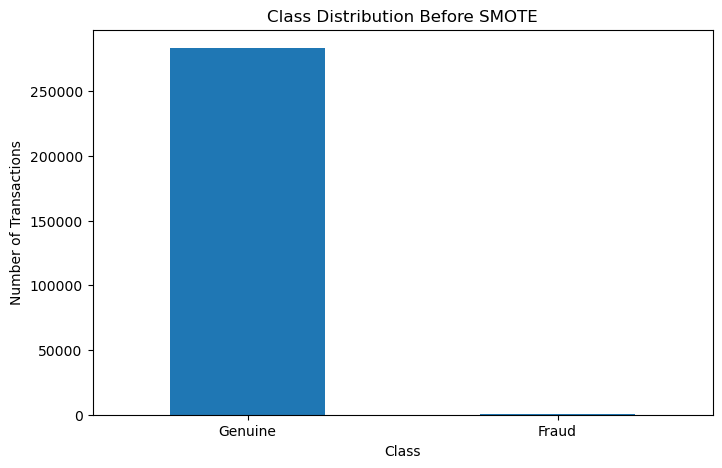

In [14]:
plt.figure(figsize=(8, 5))

df["Class"].value_counts().plot(kind="bar")

plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    ticks=[0, 1],
    labels=["Genuine", "Fraud"],
    rotation=0
)

plt.show()

Remove Temporary EDA Column

In [15]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [16]:
if "Time_Hour" in df.columns:
    df = df.drop(columns=["Time_Hour"])

In [17]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


Separate Features and Target
create X :

In [18]:
X = df.drop(columns=["Class"])

Create y:

In [19]:
y = df["Class"]

In [20]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (283726, 30)
y Shape: (283726,)


train ,test ,split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Check Split

In [22]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (226980, 30)
Testing Features: (56746, 30)
Training Target: (226980,)
Testing Target: (56746,)


Check Class Distribution Before SMOTE

In [23]:
print("Training class distribution:")
print(y_train.value_counts())

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64


In [24]:
print(
    y_train.value_counts(normalize=True) * 100
)

Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64


Feature Scaling

In [25]:
scaler = StandardScaler()

In [26]:
X_train_scaled = scaler.fit_transform(X_train)

Transform test data

In [27]:
X_test_scaled = scaler.transform(X_test)

Convert Back to DataFrame

In [28]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [29]:
X_train_scaled.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
226238,1.045499,1.147198,-1.042032,-1.428821,-1.817824,0.727198,2.695677,-1.489310,0.735746,-1.152704,...,-0.427196,-0.208573,-0.068205,0.445379,1.130202,-0.420363,-0.331281,0.092782,-0.156193,-0.229434
134253,-0.298690,-0.677911,0.991948,0.394668,-0.025642,-0.301198,-0.728240,0.175615,0.629070,-1.156290,...,-0.089833,-0.332248,-1.307141,0.518036,0.851069,-1.367338,-0.554255,-0.049864,0.153831,-0.331197
186465,0.678397,0.977654,0.016205,-1.386701,0.092688,0.850613,0.458823,-0.019872,0.154370,0.262056,...,-0.277973,0.405040,1.512732,-0.071350,-2.788905,0.202924,0.015479,0.111329,-0.165820,-0.298809
149493,-0.074929,0.927561,0.195261,0.208736,2.739855,0.032003,0.772348,-0.613532,0.199999,0.625478,...,-0.301091,0.190793,0.966846,0.278559,1.160348,-0.407893,-0.021447,-0.049724,-0.119582,-0.289247
18461,-1.376728,0.695218,-0.676118,0.363661,-1.090812,-0.882507,0.209618,-1.002620,0.182243,-1.911610,...,-0.477066,-0.473576,-0.878722,0.404329,-0.568164,-0.123705,-0.913882,0.155776,0.037290,-0.261985


Apply SMOTE

In [30]:
smote = SMOTE(
    random_state=42
)

In [31]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

Check SMOTE Result

In [32]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


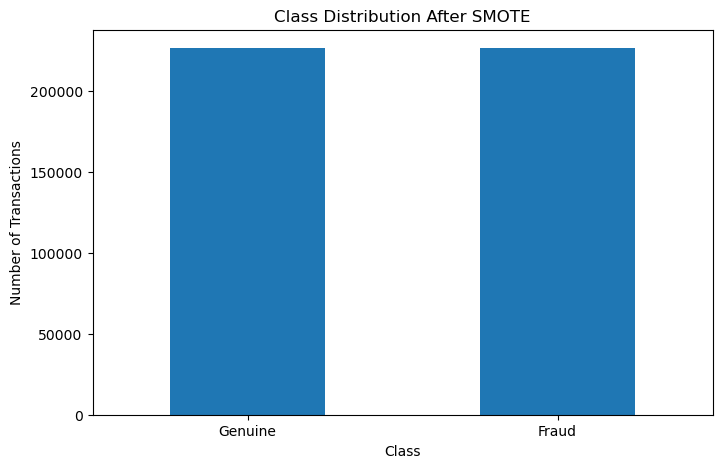

In [33]:
plt.figure(figsize=(8, 5))

y_train_smote.value_counts().plot(kind="bar")

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    ticks=[0, 1],
    labels=["Genuine", "Fraud"],
    rotation=0
)

plt.show()

Verify Shapes

In [34]:
print("X_train before SMOTE:", X_train_scaled.shape)
print("X_train after SMOTE:", X_train_smote.shape)

print("y_train before SMOTE:", y_train.shape)
print("y_train after SMOTE:", y_train_smote.shape)

X_train before SMOTE: (226980, 30)
X_train after SMOTE: (453204, 30)
y_train before SMOTE: (226980,)
y_train after SMOTE: (453204,)


Convert SMOTE DataFrame

In [35]:
X_train_smote = pd.DataFrame(
    X_train_smote,
    columns=X_train_scaled.columns
)

y_train_smote = pd.Series(
    y_train_smote,
    name="Class"
)

In [36]:
print(X_train_smote.head())
print(y_train_smote.head())

       Time        V1        V2        V3        V4        V5        V6  \
0  1.045499  1.147198 -1.042032 -1.428821 -1.817824  0.727198  2.695677   
1 -0.298690 -0.677911  0.991948  0.394668 -0.025642 -0.301198 -0.728240   
2  0.678397  0.977654  0.016205 -1.386701  0.092688  0.850613  0.458823   
3 -0.074929  0.927561  0.195261  0.208736  2.739855  0.032003  0.772348   
4 -1.376728  0.695218 -0.676118  0.363661 -1.090812 -0.882507  0.209618   

         V7        V8        V9  ...       V20       V21       V22       V23  \
0 -1.489310  0.735746 -1.152704  ... -0.427196 -0.208573 -0.068205  0.445379   
1  0.175615  0.629070 -1.156290  ... -0.089833 -0.332248 -1.307141  0.518036   
2 -0.019872  0.154370  0.262056  ... -0.277973  0.405040  1.512732 -0.071350   
3 -0.613532  0.199999  0.625478  ... -0.301091  0.190793  0.966846  0.278559   
4 -1.002620  0.182243 -1.911610  ... -0.477066 -0.473576 -0.878722  0.404329   

        V24       V25       V26       V27       V28    Amount  
0  1

Save Processed Training Data

In [37]:
train_processed = X_train_smote.copy()

train_processed["Class"] = y_train_smote.values

In [38]:
train_processed.to_csv(
    "../data/processed/train_processed.csv",
    index=False
)

Save Test Data

In [39]:
test_processed = X_test_scaled.copy()

test_processed["Class"] = y_test.values

In [40]:
test_processed.to_csv(
    "../data/processed/test_processed.csv",
    index=False
)

Save the Scaler model

In [41]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

Verify Saved Files

In [42]:
print("Processed files created successfully!")

Processed files created successfully!


Final Validation

In [43]:
train_check = pd.read_csv(
    "../data/processed/train_processed.csv"
)

test_check = pd.read_csv(
    "../data/processed/test_processed.csv"
)

print("Training Dataset:")
print(train_check.shape)

print("\nTesting Dataset:")
print(test_check.shape)

print("\nTraining Class Distribution:")
print(train_check["Class"].value_counts())

print("\nTesting Class Distribution:")
print(test_check["Class"].value_counts())

Training Dataset:
(453204, 31)

Testing Dataset:
(56746, 31)

Training Class Distribution:
Class
0    226602
1    226602
Name: count, dtype: int64

Testing Class Distribution:
Class
0    56651
1       95
Name: count, dtype: int64
